# Simple model training

Let's train simple ML models with our data in order to develop a robust model capable of accurately predicting SWF.

### Library loading

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import time
import optuna
import shap
from tabulate import tabulate
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import json
from pathlib import Path

from CIMR.SurfaceWaterFraction_ATBD_main.algorithm.processing.validation_data_processing import load_lut, unravel_freqpol, atmospheric_corrections

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error, make_scorer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import xgboost as xgb

time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

### Data setup

We'll train the models with the previous merged datasets.

In [2]:
df = pd.read_parquet("data/windsat_2017")

In [4]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

y = df['fwns']

## Variable selection

We don't just want to achieve the best posible model for SWF regression, we also need to make sure that we are relying on the main capabilities of the satalite and only using auxiliary variables when needed. For this reason, we'll study the obtained accuracy of some base models using different sets of variables.

In [10]:
models = {
    "LinearRegression": LinearRegression(),
    "XGBoost": XGBRegressor(n_estimators=20, learning_rate=0.1, max_depth=15, verbosity=0, random_state=42),
}

In [11]:
def train_and_evaluate_models_list(X_train, y_train, X_test, y_test, models):
    results_all = {}

    for name, model in models.items() if isinstance(models, dict) else models:

        start_time = time.time()
        model.fit(X_train, y_train)
        elapsed_time = time.time() - start_time

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        results = {
            "MAE_train": mean_absolute_error(y_train, y_pred_train),
            "MSE_train": mean_squared_error(y_train, y_pred_train),
            "R²_train": r2_score(y_train, y_pred_train),

            "MAE_test": mean_absolute_error(y_test, y_pred_test),
            "MSE_test": mean_squared_error(y_test, y_pred_test),
            "R²_test": r2_score(y_test, y_pred_test),

            "Tiempo": round(elapsed_time, 4)
        }

        results_all[name] = results
    return results_all

def format_results_table(results_dict, tablefmt="github"):
    df = pd.DataFrame(results_dict).T  # filas=modelos, columnas=métricas
    df = df.round(6)

    return df

### Baseline precision

There exists a physical formula for SWF using top of atmosphere brightness temperature (19H), which is what the CIMR satellites are designed to obtain, assisted with surface temperature. We'll rely on the results of this formula as a baseline in order to properly the coming results.

In [6]:
print("MAE: ", mean_absolute_error(y, df['fwns_calculated']))
print("MSE: ", mean_squared_error(y, df['fwns_calculated']))
print("R²: ", r2_score(y, df['fwns_calculated']))

MAE:  0.03340902509537092
MSE:  0.002748400523857489


R²:  0.49551178121243


In [ ]:
# -------- SET 6 --------
X6_train = df.loc[train_idx, features_6]
X6_test  = df.loc[test_idx,  features_6]
y6_train = y.loc[train_idx]
y6_test  = y.loc[test_idx]

# -------- SET 7 --------
X7_train = df.loc[train_idx, features_7]
X7_test  = df.loc[test_idx,  features_7]    
y7_train = y.loc[train_idx]
y7_test  = y.loc[test_idx]

# -------- SET 8 --------
X8_train = df.loc[train_idx, features_8]    
X8_test  = df.loc[test_idx,  features_8]
y8_train = y.loc[train_idx]
y8_test  = y.loc[test_idx]

# -------- SET 9 --------
X9_train = df.loc[train_idx, features_9]
X9_test  = df.loc[test_idx,  features_9]    
y9_train = y.loc[train_idx]
y9_test  = y.loc[test_idx]

# -------- SET 10 --------
X10_train = df.loc[train_idx, features_10]    
X10_test  = df.loc[test_idx,  features_10]
y10_train = y.loc[train_idx]
y10_test  = y.loc[test_idx]

# -------- SET 11 --------
X11_train = df.loc[train_idx, features_11]    
X11_test  = df.loc[test_idx,  features_11]
y11_train = y.loc[train_idx]
y11_test  = y.loc[test_idx]

# -------- SET 12 --------
X12_train = df.loc[train_idx, features_12]    
X12_test  = df.loc[test_idx,  features_12]
y12_train = y.loc[train_idx]
y12_test  = y.loc[test_idx]

# -------- SET 13 --------
X13_train = df.loc[train_idx, features_13]    
X13_test  = df.loc[test_idx,  features_13]
y13_train = y.loc[train_idx]
y13_test  = y.loc[test_idx]

# -------- SET 14 --------
X14_train = df.loc[train_idx, features_14]    
X14_test  = df.loc[test_idx,  features_14]
y14_train = y.loc[train_idx]
y14_test  = y.loc[test_idx]

# -------- FULL SET --------
X_full_train = df.loc[train_idx, features_all]    
X_full_test  = df.loc[test_idx,  features_all]
y_full_train = y.loc[train_idx]
y_full_test  = y.loc[test_idx]

### Necessity of surtep5

Since surtep5 is just an auxiliary variable used in the formula, let's see if it truly improves the model performance.

In [12]:
features_1 = [
    "tbtoa19H",
]

features_2 = [
    "tbtoa19H",
    "surtep_ERA5",
]

In [13]:
# -------- SET 1 --------
X1_train = df.loc[train_idx, features_1]
X1_test  = df.loc[test_idx,  features_1]
y1_train = y.loc[train_idx]
y1_test  = y.loc[test_idx]

# -------- SET 2 --------
X2_train = df.loc[train_idx, features_2]
X2_test  = df.loc[test_idx,  features_2]
y2_train = y.loc[train_idx]
y2_test  = y.loc[test_idx]

In [14]:
results1 = train_and_evaluate_models_list(X1_train, y1_train, X1_test, y1_test, models)
results2 = train_and_evaluate_models_list(X2_train, y2_train, X2_test, y2_test, models)

table1 = format_results_table(results1)
table2 = format_results_table(results2)

print(table1)
print(table2)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.034004   0.002372  0.564308  0.034026  0.002382   
XGBoost            0.027695   0.001866  0.657223  0.027731  0.001876   

                   R²_test  Tiempo  
LinearRegression  0.563688  0.1326  
XGBoost           0.656317  8.1156  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.029736   0.001956  0.640677  0.029774  0.001966   
XGBoost            0.024629   0.001501  0.724246  0.024720  0.001520   

                   R²_test   Tiempo  
LinearRegression  0.639918   0.1353  
XGBoost           0.721635  12.7186  


### Atmospheric correction

We can correct our tbtoa using atmospheric variables before training. This will hopefully improve the performance of the model. Let's also check if just adding the variables involved in the correction into the training yields better results.

In [15]:
features_3 = [
    "tbboa_de_lannoy19H",
    "surtep_ERA5",
]

features_4 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "surtep_ERA5",
]

features_5 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbboa_1st_order19H",
    "tbboa_de_lannoy19H",
    "surtep_ERA5",
]

In [16]:
# -------- SET 3 --------
X3_train = df.loc[train_idx, features_3]
X3_test  = df.loc[test_idx,  features_3]
y3_train = y.loc[train_idx]
y3_test  = y.loc[test_idx]

# -------- SET 4 --------
X4_train = df.loc[train_idx, features_4]
X4_test  = df.loc[test_idx,  features_4]
y4_train = y.loc[train_idx]
y4_test  = y.loc[test_idx]

# -------- SET 5 --------
X5_train = df.loc[train_idx, features_5]
X5_test  = df.loc[test_idx,  features_5]
y5_train = y.loc[train_idx]
y5_test  = y.loc[test_idx]

In [17]:
results3 = train_and_evaluate_models_list(X3_train, y3_train, X3_test, y3_test, models)
results4 = train_and_evaluate_models_list(X4_train, y4_train, X4_test, y4_test, models)
results5 = train_and_evaluate_models_list(X5_train, y5_train, X5_test, y5_test, models)

table3 = format_results_table(results3)
table4 = format_results_table(results4)
table5 = format_results_table(results5)

print(table3)
print(table4)
print(table5)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.029596   0.001936  0.644408  0.029634  0.001946   
XGBoost            0.024522   0.001488  0.726721  0.024610  0.001506   

                   R²_test   Tiempo  
LinearRegression  0.643634   0.1366  
XGBoost           0.724183  12.8109  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.028856   0.001817  0.666333  0.028900  0.001826   
XGBoost            0.020989   0.001157  0.787584  0.021526  0.001249   

                   R²_test   Tiempo  
LinearRegression  0.665519   0.2940  
XGBoost           0.771178  18.6752  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.026528   0.001637  0.699411  0.026566  0.001645   
XGBoost            0.020977   0.001155  0.787955  0.021530  0.001250   

                   R²_test   Tiempo  
LinearRegression  0.698676   0.4267  
XGBoost           0.771086  22.0858  


### Lookup tables

In [18]:
features_6 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "surtep_ERA5",
    "vsm",
    "VOD"
]

features_7 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "surtep_ERA5",
    "ref_land_emis_de_lannoy_K_h",
    "ref_land_emis_de_lannoy_K_v"
]

features_8 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "surtep_ERA5",
    "vsm",
    "VOD",
    "ref_land_emis_de_lannoy_K_h",
    "ref_land_emis_de_lannoy_K_v"
]

In [19]:
# -------- SET 6 --------
X6_train = df.loc[train_idx, features_6]
X6_test  = df.loc[test_idx,  features_6]
y6_train = y.loc[train_idx]
y6_test  = y.loc[test_idx]

# -------- SET 7 --------
X7_train = df.loc[train_idx, features_7]
X7_test  = df.loc[test_idx,  features_7]
y7_train = y.loc[train_idx]
y7_test  = y.loc[test_idx]

# -------- SET 8 --------
X8_train = df.loc[train_idx, features_8]
X8_test  = df.loc[test_idx,  features_8]
y8_train = y.loc[train_idx]
y8_test  = y.loc[test_idx]

In [20]:
results6 = train_and_evaluate_models_list(X6_train, y6_train, X6_test, y6_test, models)
results7 = train_and_evaluate_models_list(X7_train, y7_train, X7_test, y7_test, models)
results8 = train_and_evaluate_models_list(X8_train, y8_train, X8_test, y8_test, models)

table6 = format_results_table(results6)
table7 = format_results_table(results7)
table8 = format_results_table(results8)

print(table6)
print(table7)
print(table8)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.022200   0.001100   0.79795  0.022230  0.001107   
XGBoost            0.015288   0.000607   0.88846  0.015894  0.000690   

                   R²_test   Tiempo  
LinearRegression  0.797322   0.4664  
XGBoost           0.873534  21.8281  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.021606   0.001127  0.793016  0.021642  0.001134   
XGBoost            0.016175   0.000690  0.873255  0.016633  0.000758   

                   R²_test   Tiempo  
LinearRegression  0.792307   0.9145  
XGBoost           0.861136  19.9636  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.020104   0.000979  0.820247  0.020132  0.000984   
XGBoost            0.015294   0.000608  0.888416  0.015896  0.000691   

                   R²_test   Tiempo  
LinearRegression  0.819731   1.2803  
XGBoost           0.873478  23.3605  


### Adding new polarization and frequencies

In [21]:
features_9 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "surtep_ERA5",
    "vsm",
    "VOD"
]

features_10 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD"
]

In [22]:
# -------- SET 9 --------
X9_train = df.loc[train_idx, features_9]
X9_test  = df.loc[test_idx,  features_9]
y9_train = y.loc[train_idx]
y9_test  = y.loc[test_idx]

# -------- SET 10 --------
X10_train = df.loc[train_idx, features_10]
X10_test  = df.loc[test_idx,  features_10]
y10_train = y.loc[train_idx]
y10_test  = y.loc[test_idx]

In [23]:
results9 = train_and_evaluate_models_list(X9_train, y9_train, X9_test, y9_test, models)
results10 = train_and_evaluate_models_list(X10_train, y10_train, X10_test, y10_test, models)

table9 = format_results_table(results9)
table10 = format_results_table(results10)

print(table9)
print(table10)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.021609   0.001055  0.806162  0.021639  0.001062   
XGBoost            0.013933   0.000518  0.904879  0.014575  0.000601   

                   R²_test   Tiempo  
LinearRegression  0.805465   0.8266  
XGBoost           0.889850  27.7973  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.019676   0.000925  0.830062  0.019705  0.000931   
XGBoost            0.013214   0.000449  0.917472  0.013857  0.000530   

                   R²_test   Tiempo  
LinearRegression  0.829392   1.6248  
XGBoost           0.903005  38.4889  


### Feature engeneering

In [25]:
features_11 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD",
    'emiss19H_de_lannoy',
    'emiss19V_de_lannoy',
    'emiss37H_de_lannoy',
    'emiss37V_de_lannoy',
]

features_12 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD",
    'emiss19H_de_lannoy',
    'emiss19V_de_lannoy',
    'emiss37H_de_lannoy',
    'emiss37V_de_lannoy',
    'denominator',
    'term_1',
    'term_2',
    'fwns_calculated'
]

In [26]:
# -------- SET 11 --------
X11_train = df.loc[train_idx, features_11]
X11_test  = df.loc[test_idx,  features_11]
y11_train = y.loc[train_idx]
y11_test  = y.loc[test_idx]

# -------- SET 12 --------
X12_train = df.loc[train_idx, features_12]
X12_test  = df.loc[test_idx,  features_12]
y12_train = y.loc[train_idx]
y12_test  = y.loc[test_idx]

In [27]:
results11 = train_and_evaluate_models_list(X11_train, y11_train, X11_test, y11_test, models)
results12 = train_and_evaluate_models_list(X12_train, y12_train, X12_test, y12_test, models)

table11 = format_results_table(results11)
table12 = format_results_table(results12)

print(table11)
print(table12)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.019194   0.000881  0.838226  0.019218  0.000887   
XGBoost            0.013078   0.000445  0.918288  0.013691  0.000520   

                   R²_test   Tiempo  
LinearRegression  0.837579   1.9519  
XGBoost           0.904768  44.1370  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.018278   0.000829  0.847736  0.018305  0.000835   
XGBoost            0.013121   0.000447  0.917895  0.013733  0.000523   

                   R²_test   Tiempo  
LinearRegression  0.847049   5.0319  
XGBoost           0.904264  45.2485  


### New auxiliary variables

In [ ]:
features_13 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD",
    'clase'
]

features_14 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD",
    'Tmn',
    'PWV',
    'VPD'
]

features_15 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD",
    'clase',
    'Tmn',
    'PWV',
    'VPD'
]

# features_all = [c for c in df.columns if c != "fwns"]

In [29]:
# -------- SET 13 --------
X13_train = df.loc[train_idx, features_13]
X13_test  = df.loc[test_idx,  features_13]
y13_train = y.loc[train_idx]
y13_test  = y.loc[test_idx]

# -------- SET 14 --------
X14_train = df.loc[train_idx, features_14]
X14_test  = df.loc[test_idx,  features_14]
y14_train = y.loc[train_idx]
y14_test  = y.loc[test_idx]

# -------- SET 15 --------
X15_train = df.loc[train_idx, features_15]
X15_test  = df.loc[test_idx,  features_15]
y15_train = y.loc[train_idx]
y15_test  = y.loc[test_idx]

In [30]:
results13 = train_and_evaluate_models_list(X13_train, y13_train, X13_test, y13_test, models)
results14 = train_and_evaluate_models_list(X14_train, y14_train, X14_test, y14_test, models)
results15 = train_and_evaluate_models_list(X15_train, y15_train, X15_test, y15_test, models)

table13 = format_results_table(results13)
table14 = format_results_table(results14)
table15 = format_results_table(results15)

print(table13)
print(table14)
print(table15)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.019660   0.000923  0.830465  0.019688  0.000929   
XGBoost            0.013097   0.000436  0.919860  0.013726  0.000513   

                   R²_test   Tiempo  
LinearRegression  0.829805   3.9909  
XGBoost           0.905958  40.0902  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.018823   0.000864  0.841284  0.018848  0.000870   
XGBoost            0.011779   0.000364  0.933089  0.012394  0.000433   

                   R²_test   Tiempo  
LinearRegression  0.840630   1.8219  
XGBoost           0.920704  41.7517  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.018834   0.000864  0.841287  0.018858  0.000870   
XGBoost            0.011714   0.000358  0.934281  0.012321  0.000425   

                   R²_test   Tiempo  
LinearRegression  0.840631   4.0661  
XGBoost           0.922184  44.0443  


## Explainability

In [8]:
XGB = XGBRegressor(n_estimators=20, learning_rate=0.1, max_depth=15, verbosity=0, random_state=42)
XGB.fit(X_full_train, y_full_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
# X_test: pandas DataFrame, y_test: Series or array
dtest = xgb.DMatrix(X_full_test, label=y_full_test)

# Get booster from your trained XGBRegressor
booster = XGB.get_booster()

# GPU-accelerated SHAP values
shap_values = booster.predict(dtest, pred_contribs=True)

In [10]:
# Sample 5k rows (adjust as needed)
X_sample = X_full_test.sample(5000, random_state=42)
y_sample = y_full_test.loc[X_sample.index]

# Get booster from your trained XGBRegressor
booster = XGB.get_booster()

dtest = xgb.DMatrix(X_sample, label=y_sample)
shap_values = booster.predict(dtest, pred_contribs=True)

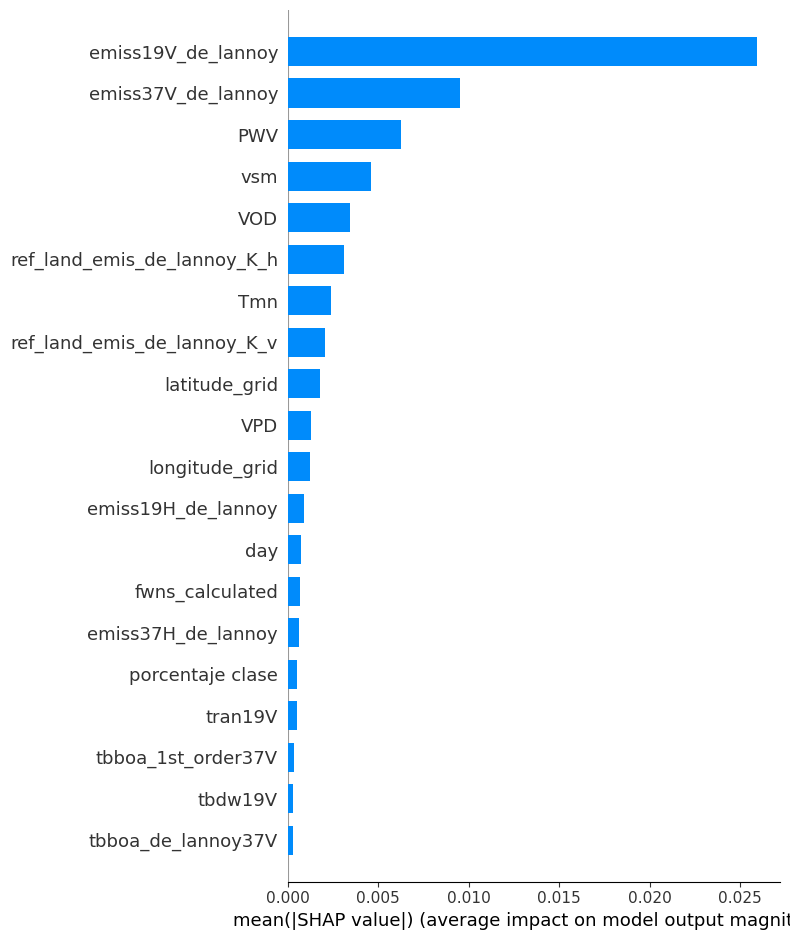

In [11]:
# Remove last column (bias) if you want just feature contributions
shap_values_features = shap_values[:, :-1]

shap.summary_plot(
    shap_values_features,
    X_full_test,
    plot_type="bar",
    show=True
)

## Optimazation

Although the results we've obtained are a good first impresion of the accuracy of the models, these can be highly hindered by our choice of hyperparameters. We can fix this by optimizing said parameters, in hope of obtaining the true performance of every model.

In [12]:
def save_study_results(study, model_name, output_dir="optuna_results"):
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    payload = {
        "model": model_name,
        "best_value_rmse": study.best_value,
        "best_params": study.best_params
    }

    with open(output_dir / f"{model_name}_best_params.json", "w") as f:
        json.dump(payload, f, indent=4)

In [15]:
def objective_xgb(trial):
    model = XGBRegressor(
        n_estimators=2000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 4, 12),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0, 5),
        min_child_weight=trial.suggest_float("min_child_weight", 1e-2, 10, log=True),
        device="cuda",
        tree_method="hist",
        n_jobs=1,              # keep single-threaded for stability
        verbosity=0,
        random_state=42
    )

    model.fit(X4_train, y4_train)
    preds = model.predict(X4_test)

    rmse = np.sqrt(mean_squared_error(y4_test, preds))
    return -rmse

In [ ]:
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=5)

print("Best RMSE:", -study_xgb.best_value)
print("Best params:", study_xgb.best_params)

save_study_results(study_xgb, "xgboost")

[I 2026-02-09 20:02:13,465] A new study created in memory with name: no-name-b6bd0a05-1e6c-4701-891e-38d8c501189f
[I 2026-02-09 20:04:04,177] Trial 0 finished with value: -0.023044157726723212 and parameters: {'learning_rate': 0.0256470843983606, 'max_depth': 8, 'subsample': 0.7184712404719148, 'colsample_bytree': 0.9668805143695447, 'gamma': 3.774840455164421, 'min_child_weight': 0.02418656205475643}. Best is trial 0 with value: -0.023044157726723212.
[I 2026-02-09 20:06:26,847] Trial 1 finished with value: -0.02322470153467578 and parameters: {'learning_rate': 0.05150586915307011, 'max_depth': 7, 'subsample': 0.9575805495499558, 'colsample_bytree': 0.6312036057368066, 'gamma': 3.9627874408263377, 'min_child_weight': 0.015096025117914006}. Best is trial 0 with value: -0.023044157726723212.
[I 2026-02-09 20:08:39,659] Trial 2 finished with value: -0.021876975857958118 and parameters: {'learning_rate': 0.060391136834579334, 'max_depth': 12, 'subsample': 0.987093911253599, 'colsample_byt

Best RMSE: -0.020941397621967395
Best params: {'learning_rate': 0.053049527081118056, 'max_depth': 12, 'subsample': 0.7605323064542029, 'colsample_bytree': 0.8196136860746557, 'gamma': 0.7788597278933823, 'min_child_weight': 0.05013328776158206}


## Explainability

One of the key advantages of simple machine learning models over neural networks is explainability, the process by which we can understand the inner workings of a trained model. We'll analyze the final model in order to determine which variables were key when predicting SWF using shapely values.

In [7]:
with open("optuna_results/xgboost_best_params.json", "r") as f:
    data = json.load(f)

best_params = data["best_params"]

final_model = XGBRegressor(
    **best_params,
    n_estimators=2000,
    tree_method="hist",
    device="cuda",
    n_jobs=1,
    verbosity=0,
    random_state=42
)

final_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9317330015162258
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [8]:
preds = final_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"Final XGBoost RMSE: {rmse:.5f}")
print(f"Final XGBoost R²:   {r2:.5f}")

Final XGBoost RMSE: 0.02315
Final XGBoost R²:   0.90973


In order to extract the SHAP values using our GPU, we'll have to work with the underlying architecture of XGBoost.

In [9]:
# X_test: pandas DataFrame, y_test: Series or array
dtest = xgb.DMatrix(X_test, label=y_test)

# Get booster from your trained XGBRegressor
booster = final_model.get_booster()

# GPU-accelerated SHAP values
shap_values = booster.predict(dtest, pred_contribs=True)

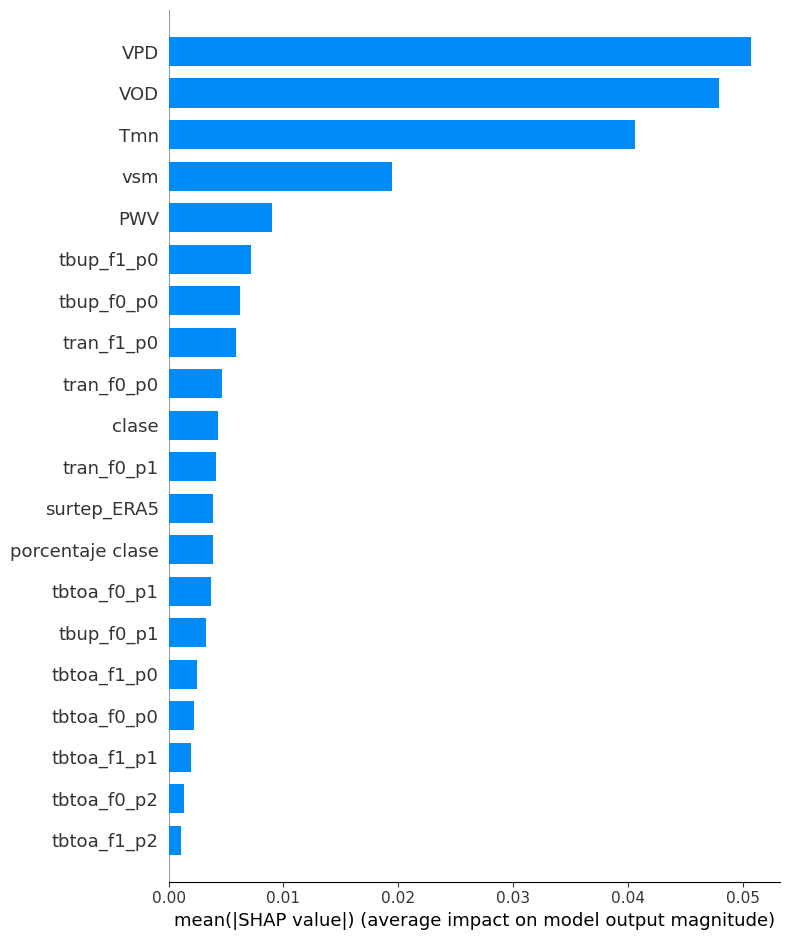

In [10]:
# Remove last column (bias) if you want just feature contributions
shap_values_features = shap_values[:, :-1]

shap.summary_plot(
    shap_values_features,
    X_test,
    plot_type="bar",
    show=True
)